<a href="https://colab.research.google.com/github/santiagofdzhdz-lab/markowitz-portfolio-optimization/blob/main/%20%20%20markowitz_monte_carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Markowitz Portfolio Optimization — Monte Carlo Simulation

In [ ]:
# ============================================================
# INTERRUPTOR DE GRAFICAS - esta es la SEGUNDA celda del notebook
# (la primera es el titulo).
#
# Busca la linea de abajo que dice: MOSTRAR_FIJAS = ...
#   MOSTRAR_FIJAS = True   -> graficas FIJAS (imagen). Usalo en el CELULAR.
#   MOSTRAR_FIJAS = False  -> graficas INTERACTIVAS (hover, zoom). Usalo en COMPUTADORA.
#
# Cambia esa palabra (True o False), luego:
#   1) Entorno de ejecucion -> Reiniciar sesion
#   2) Entorno de ejecucion -> Ejecutar todo
# ============================================================

MOSTRAR_FIJAS = True   # <---- CAMBIA AQUI: True (celular) o False (computadora)

!pip install -q "kaleido==0.2.1"
import plotly.graph_objects as go
from IPython.display import Image, display
import uuid

if MOSTRAR_FIJAS:
    def _show_fija(self, *args, **kwargs):
        filename = f"_plot_{uuid.uuid4().hex}.png"
        self.write_image(filename, engine="kaleido")
        display(Image(filename))
    go.Figure.show = _show_fija
    print("MODO CELULAR: graficas fijas activadas.")
else:
    print("MODO COMPUTADORA: graficas interactivas activadas (normal de Plotly).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.6 MB/s eta 0:00:00
MODO CELULAR: graficas fijas activadas.


In [ ]:
# ============================================================
# DESCARGA DE DATOS DESDE YAHOO FINANCE (yfinance)
# Corre esta celda primero para generar Amazon.csv, JPM.csv y stock_prices.csv
# ============================================================
!pip install yfinance -q
import yfinance as yf
import pandas as pd

end = '2022-12-17'  # yfinance no incluye el "end", por eso un dia despues del 16-Dic-2022

# --- Amazon.csv ---
amzn = yf.download('AMZN', start='2018-01-02', end=end, auto_adjust=False)
amzn = amzn.reset_index()
amzn.columns = [c[0] if isinstance(c, tuple) else c for c in amzn.columns]
amzn = amzn[['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']]
amzn.to_csv('Amazon.csv', index=False)

# --- JPM.csv ---
jpm = yf.download('JPM', start='2017-07-14', end=end, auto_adjust=False)
jpm = jpm.reset_index()
jpm.columns = [c[0] if isinstance(c, tuple) else c for c in jpm.columns]
jpm = jpm[['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']]
jpm.to_csv('JPM.csv', index=False)

# --- stock_prices.csv (precios de cierre ajustado de 10 acciones) ---
tickers = ['AMZN', 'CAT', 'DE', 'EXC', 'GOOGL', 'JNJ', 'JPM', 'META', 'PFE', 'PG']
raw = yf.download(tickers, start='2014-01-02', end=end, auto_adjust=False)['Adj Close']
raw = raw[tickers]  # mismo orden que el notebook original
raw = raw.reset_index()
raw.to_csv('stock_prices.csv', index=False)

print('Listos: Amazon.csv, JPM.csv, stock_prices.csv')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  10 of 10 completed

Listos: Amazon.csv, JPM.csv, stock_prices.csv


In [ ]:
# Import key librares and modules
import pandas as pd
import numpy as np

# FIX: numpy 2.x cambio como se ve el repr() de sus numeros (ej. np.float64(1.0)
# en vez de 1.0), y eso rompe a cufflinks cuando arma colores tipo "rgba(...)".
# Esta linea restaura el formato viejo sin tener que desinstalar/bajar numpy.
np.set_printoptions(legacy="1.25")

# Import datetime module that comes pre-installed in Python
# datetime offers classes that work with date & time information
import datetime as dt

In [ ]:
# Use Pandas to read stock data (the csv file is included in the course package)
stock_df = pd.read_csv('Amazon.csv')
stock_df.head(15)

,Date,Open,High,Low,Close,Volume,Adj Close
0,2018-01-02,58.599998,59.500000,58.525501,59.450500,53890000,59.450500
1,2018-01-03,59.415001,60.274502,59.415001,60.209999,62176000,60.209999
2,2018-01-04,60.250000,60.793499,60.233002,60.479500,60442000,60.479500
3,2018-01-05,60.875500,61.457001,60.500000,61.457001,70894000,61.457001
4,2018-01-08,61.799999,62.653999,61.601501,62.343498,85590000,62.343498
5,2018-01-09,62.845001,62.966499,62.088001,62.634998,73226000,62.634998
6,2018-01-10,62.257500,62.716499,61.861500,62.716499,53720000,62.716499
7,2018-01-11,62.987000,63.838501,62.823002,63.834000,62500000,63.834000
8,2018-01-12,63.669498,65.288002,63.669498,65.260002,108874000,65.260002
9,2018-01-16,66.150002,66.997002,64.614998,65.242996,144414000,65.242996


In [ ]:
# Count the number of missing values in "stock_df" Pandas DataFrame
stock_df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Adj Close,0


In [ ]:
# Obtain information about the Pandas DataFrame such as data types, memory utilization..etc
stock_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1250 non-null   object 
 1   Open       1250 non-null   float64
 2   High       1250 non-null   float64
 3   Low        1250 non-null   float64
 4   Close      1250 non-null   float64
 5   Volume     1250 non-null   int64  
 6   Adj Close  1250 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 68.5+ KB


In [ ]:
# Calculate the percentage daily return
stock_df['Daily Return'] = stock_df['Adj Close'].pct_change(1) * 100
stock_df

,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return
0,2018-01-02,58.599998,59.500000,58.525501,59.450500,53890000,59.450500,NaN
1,2018-01-03,59.415001,60.274502,59.415001,60.209999,62176000,60.209999,1.277531
2,2018-01-04,60.250000,60.793499,60.233002,60.479500,60442000,60.479500,0.447601
3,2018-01-05,60.875500,61.457001,60.500000,61.457001,70894000,61.457001,1.616252
4,2018-01-08,61.799999,62.653999,61.601501,62.343498,85590000,62.343498,1.442468
...,...,...,...,...,...,...,...,...
1245,2022-12-12,89.209999,90.580002,87.870003,90.550003,61999800,90.550003,1.638800
1246,2022-12-13,95.230003,96.250000,90.519997,92.489998,100212000,92.489998,2.142457
1247,2022-12-14,92.500000,93.459999,89.870003,91.580002,70298000,91.580002,-0.983886
1248,2022-12-15,89.889999,89.970001,87.470001,88.449997,84802900,88.449997,-3.417782


In [ ]:
# Let's replace the first row with zeros instead of NaN
stock_df['Daily Return'].replace(np.nan, 0, inplace = True)
stock_df

/tmp/ipykernel_499/4192783257.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stock_df['Daily Return'].replace(np.nan, 0, inplace = True)


,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return
0,2018-01-02,58.599998,59.500000,58.525501,59.450500,53890000,59.450500,0.000000
1,2018-01-03,59.415001,60.274502,59.415001,60.209999,62176000,60.209999,1.277531
2,2018-01-04,60.250000,60.793499,60.233002,60.479500,60442000,60.479500,0.447601
3,2018-01-05,60.875500,61.457001,60.500000,61.457001,70894000,61.457001,1.616252
4,2018-01-08,61.799999,62.653999,61.601501,62.343498,85590000,62.343498,1.442468
...,...,...,...,...,...,...,...,...
1245,2022-12-12,89.209999,90.580002,87.870003,90.550003,61999800,90.550003,1.638800
1246,2022-12-13,95.230003,96.250000,90.519997,92.489998,100212000,92.489998,2.142457
1247,2022-12-14,92.500000,93.459999,89.870003,91.580002,70298000,91.580002,-0.983886
1248,2022-12-15,89.889999,89.970001,87.470001,88.449997,84802900,88.449997,-3.417782


In [ ]:
# Use the describe() method to obtain a statistical summary about the data
# Over the specified time period, the average adjusted close price for Amazon stock was $120.07
# The maximum adjusted close price was $186.57
# The maximum volume of shares traded on one day were 311,346,000
stock_df.describe().round(2)

,Open,High,Low,Close,Volume,Adj Close,Daily Return
count,1250.00,1250.00,1250.00,1250.00,1.250000e+03,1250.00,1250.00
mean,120.15,121.59,118.54,120.07,8.670837e+07,120.07,0.06
std,35.66,36.04,35.23,35.59,4.077830e+07,35.59,2.25
min,58.60,59.50,58.53,59.45,1.762600e+07,59.45,-14.05
25%,89.21,89.90,88.10,89.13,5.897078e+07,89.13,-1.04
50%,108.29,111.70,106.86,108.73,7.515300e+07,108.73,0.12
75%,158.39,160.05,156.28,158.11,1.027868e+08,158.11,1.17
max,187.20,188.65,184.84,186.57,3.113460e+08,186.57,13.54


In [ ]:
# Matplotlib is a comprehensive data visualization library in Python
# Seaborn is a visualization library that sits on top of matplotlib and offers enhanced features
# plotly.express module contains functions that can create interactive figures using a few lines of code

import matplotlib.pyplot as plt

!pip install seaborn
import seaborn as sns

import plotly.express as px

In [ ]:
# Plot a Line Plot Using Plotly Express
fig = px.line(title = 'Amazon.com, Inc. (AMZN) Adjusted Closing Price [$]')
fig.add_scatter(x = stock_df['Date'], y = stock_df['Adj Close'], name = 'Adj Close')

In [ ]:
stock_df

,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return
0,2018-01-02,58.599998,59.500000,58.525501,59.450500,53890000,59.450500,0.000000
1,2018-01-03,59.415001,60.274502,59.415001,60.209999,62176000,60.209999,1.277531
2,2018-01-04,60.250000,60.793499,60.233002,60.479500,60442000,60.479500,0.447601
3,2018-01-05,60.875500,61.457001,60.500000,61.457001,70894000,61.457001,1.616252
4,2018-01-08,61.799999,62.653999,61.601501,62.343498,85590000,62.343498,1.442468
...,...,...,...,...,...,...,...,...
1245,2022-12-12,89.209999,90.580002,87.870003,90.550003,61999800,90.550003,1.638800
1246,2022-12-13,95.230003,96.250000,90.519997,92.489998,100212000,92.489998,2.142457
1247,2022-12-14,92.500000,93.459999,89.870003,91.580002,70298000,91.580002,-0.983886
1248,2022-12-15,89.889999,89.970001,87.470001,88.449997,84802900,88.449997,-3.417782


In [ ]:
# Define a function that performs interactive data visualization using Plotly Express
def plot_financial_data(df, title):

    fig = px.line(title = title)

    # For loop that plots all stock prices in the pandas dataframe df
    # Note that index starts with 1 because we want to skip the date column

    for i in df.columns[1:]:
        fig.add_scatter(x = df['Date'], y = df[i], name = i)
        fig.update_traces(line_width = 5)
        fig.update_layout({'plot_bgcolor': "white"})

    fig.show()  # usa el monkeypatch global de arriba -> se muestra como PNG estatico

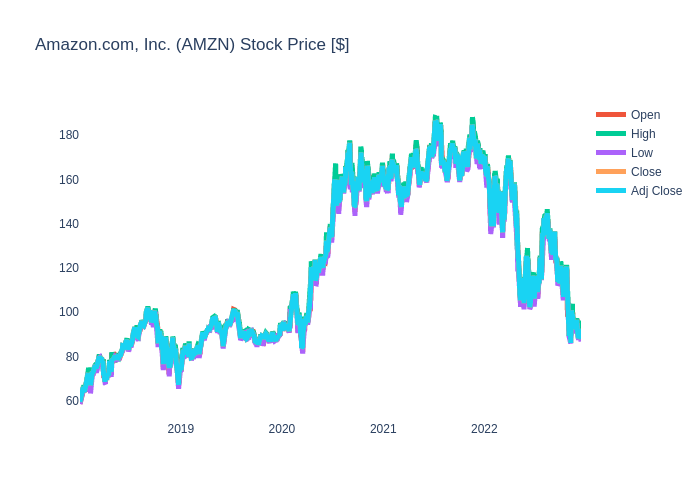

In [ ]:
# Plot High, Low, Open, Close and Adj Close
plot_financial_data(stock_df.drop(['Volume', 'Daily Return'], axis = 1), 'Amazon.com, Inc. (AMZN) Stock Price [$]')

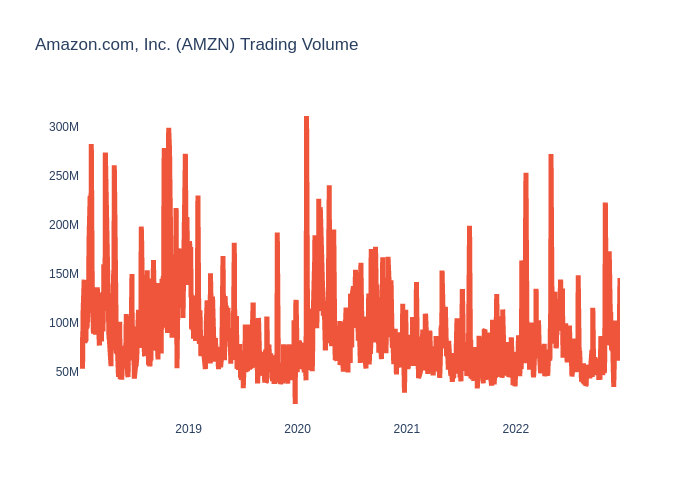

In [ ]:
# Plot trading volume
plot_financial_data(stock_df.iloc[:,[0,5]], 'Amazon.com, Inc. (AMZN) Trading Volume')

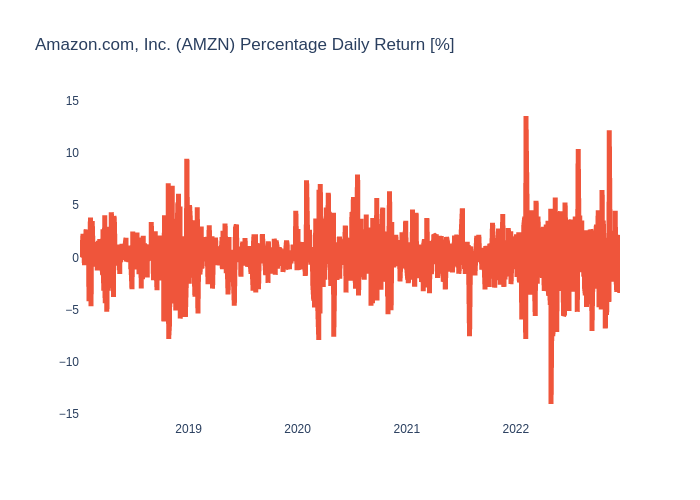

In [ ]:
# Plot % Daily Returns
plot_financial_data(stock_df.iloc[:,[0,7]], 'Amazon.com, Inc. (AMZN) Percentage Daily Return [%]')

In [ ]:
# Define a function that classifies the returns based on the magnitude
# Feel free to change these numbers
def percentage_return_classifier(percentage_return):

    if percentage_return > -0.3 and percentage_return <= 0.3:
        return 'Insignificant Change'
    elif percentage_return > 0.3 and percentage_return <= 3:
        return 'Positive Change'
    elif percentage_return > -3 and percentage_return <= -0.3:
        return 'Negative Change'
    elif percentage_return > 3 and percentage_return <= 7:
        return 'Large Positive Change'
    elif percentage_return > -7 and percentage_return <= -3:
        return 'Large Negative Change'
    elif percentage_return > 7:
        return 'Bull Run'
    elif percentage_return <= -7:
        return 'Bear Sell Off'

In [ ]:
# Apply the function to the "Daily Return" Column and place the result in "Trend" column
stock_df['Trend'] = stock_df['Daily Return'].apply(percentage_return_classifier)
stock_df

,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return,Trend
0,2018-01-02,58.599998,59.500000,58.525501,59.450500,53890000,59.450500,0.000000,Insignificant Change
1,2018-01-03,59.415001,60.274502,59.415001,60.209999,62176000,60.209999,1.277531,Positive Change
2,2018-01-04,60.250000,60.793499,60.233002,60.479500,60442000,60.479500,0.447601,Positive Change
3,2018-01-05,60.875500,61.457001,60.500000,61.457001,70894000,61.457001,1.616252,Positive Change
4,2018-01-08,61.799999,62.653999,61.601501,62.343498,85590000,62.343498,1.442468,Positive Change
...,...,...,...,...,...,...,...,...,...
1245,2022-12-12,89.209999,90.580002,87.870003,90.550003,61999800,90.550003,1.638800,Positive Change
1246,2022-12-13,95.230003,96.250000,90.519997,92.489998,100212000,92.489998,2.142457,Positive Change
1247,2022-12-14,92.500000,93.459999,89.870003,91.580002,70298000,91.580002,-0.983886,Negative Change
1248,2022-12-15,89.889999,89.970001,87.470001,88.449997,84802900,88.449997,-3.417782,Large Negative Change


In [ ]:
# Count distinct values in the Trend column
trend_summary = stock_df['Trend'].value_counts()
trend_summary

,count
Trend,
Positive Change,470
Negative Change,405
Insignificant Change,190
Large Positive Change,86
Large Negative Change,82
Bear Sell Off,9
Bull Run,8


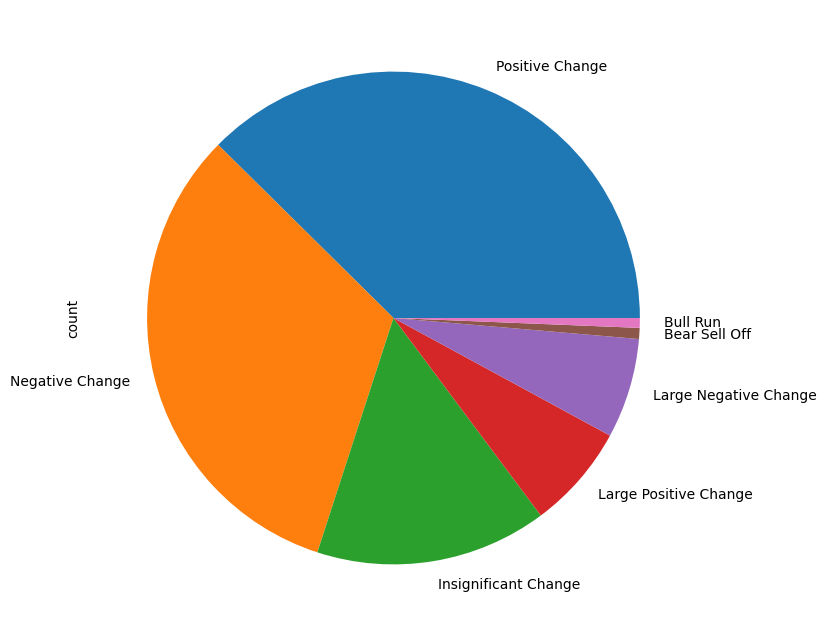

In [ ]:
# Plot a pie chart using Matplotlib Library
plt.figure(figsize = (8, 8))
trend_summary.plot(kind = 'pie', y = 'Trend');

In [ ]:
# Let's plot a candlestick graph using Cufflinks library
# Cufflinks is a powerful Python library that connects Pandas and Plotly for generating plots using few lines of code
# Cufflinks allows for interactive data visualization
! pip install cufflinks
import cufflinks as cf
cf.go_offline() # Enabling offline mode for interactive data visualization locally

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 24.0 MB/s eta 0:00:00


In [ ]:
stock_df

,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return,Trend
0,2018-01-02,58.599998,59.500000,58.525501,59.450500,53890000,59.450500,0.000000,Insignificant Change
1,2018-01-03,59.415001,60.274502,59.415001,60.209999,62176000,60.209999,1.277531,Positive Change
2,2018-01-04,60.250000,60.793499,60.233002,60.479500,60442000,60.479500,0.447601,Positive Change
3,2018-01-05,60.875500,61.457001,60.500000,61.457001,70894000,61.457001,1.616252,Positive Change
4,2018-01-08,61.799999,62.653999,61.601501,62.343498,85590000,62.343498,1.442468,Positive Change
...,...,...,...,...,...,...,...,...,...
1245,2022-12-12,89.209999,90.580002,87.870003,90.550003,61999800,90.550003,1.638800,Positive Change
1246,2022-12-13,95.230003,96.250000,90.519997,92.489998,100212000,92.489998,2.142457,Positive Change
1247,2022-12-14,92.500000,93.459999,89.870003,91.580002,70298000,91.580002,-0.983886,Negative Change
1248,2022-12-15,89.889999,89.970001,87.470001,88.449997,84802900,88.449997,-3.417782,Large Negative Change


In [ ]:
# Set the date to be the index for the Pandas DataFrame
# This is critical to show the date on the x-axis when using cufflinks
if stock_df.index.name != 'Date':
    stock_df.set_index(['Date'], inplace = True)
stock_df

,Open,High,Low,Close,Volume,Adj Close,Daily Return,Trend
Date,,,,,,,,
2018-01-02,58.599998,59.500000,58.525501,59.450500,53890000,59.450500,0.000000,Insignificant Change
2018-01-03,59.415001,60.274502,59.415001,60.209999,62176000,60.209999,1.277531,Positive Change
2018-01-04,60.250000,60.793499,60.233002,60.479500,60442000,60.479500,0.447601,Positive Change
2018-01-05,60.875500,61.457001,60.500000,61.457001,70894000,61.457001,1.616252,Positive Change
2018-01-08,61.799999,62.653999,61.601501,62.343498,85590000,62.343498,1.442468,Positive Change
...,...,...,...,...,...,...,...,...
2022-12-12,89.209999,90.580002,87.870003,90.550003,61999800,90.550003,1.638800,Positive Change
2022-12-13,95.230003,96.250000,90.519997,92.489998,100212000,92.489998,2.142457,Positive Change
2022-12-14,92.500000,93.459999,89.870003,91.580002,70298000,91.580002,-0.983886,Negative Change


In [ ]:
# Plot Candlestick figure using Cufflinks QuantFig module
figure = cf.QuantFig(stock_df, title = 'Amazon.com, Inc. (AMZN) Candlestick Chart', name = 'AMZN')
figure.add_sma(periods=[14, 21], column = 'Close', color = ['magenta', 'green'])
figure.iplot(theme = 'white', up_color = 'green', down_color = 'red')

## Perform data visualization for multiple stocks

In [ ]:
# Let's read multiple stocks data contained in "stock_prices.csv" attached in the course package
# The Appendix includes details on how to obtain this data using yfinance and Pandas Datareader
# Note that yfinance and Pandas Datareader might experience outage in some geographical regions

# We will focus our analysis on U.S. stocks, similar analysis could be performed on Asian, European or African stocks
# AMZN: Amazon Inc. - Multinational tech company focusing on e-commerce, cloud computing, and artificial intelligence
# JPM: JPMorgan Chase and Co. - Multinational investment bank and financial services holding company
# META: Meta Platforms, formerly named Facebook Inc. - META owns Facebook, Instagram, and WhatsApp
# PG: Procter and Gamble (P&G) - Multinational consumer goods corporation
# GOOG: Google (Alphabet Inc.) - Multinational company that focuses on search engine tech, e-commerce, Cloud and AI
# CAT: Caterpillar - World's largest construction-equipment manufacturer
# PFE: Pfizer Inc. - Multinational pharmaceutical and biotechnology corporation
# EXC: Exelon - An American Fortune 100 energy company
# DE: Deere & Company (John Deere) - Manufactures agricultural machinery and heavy equipment
# JNJ: Johnson & Johnson - A multinational corporation that develops medical devices and pharmaceuticals

close_price_df = pd.read_csv('stock_prices.csv')
close_price_df

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,2014-01-02,19.898500,65.644272,71.915642,12.284677,27.593288,64.182755,41.794571,54.233742,16.690779,56.173172
1,2014-01-03,19.822001,65.607735,72.234375,12.035998,27.391998,64.760872,42.117672,54.085052,16.723660,56.110413
2,2014-01-06,19.681499,64.745827,71.636795,12.112864,27.697399,65.099342,42.361786,56.702065,16.740099,56.242928
3,2014-01-07,19.901501,64.957626,71.955521,12.176160,28.231358,66.481270,41.873547,57.415794,16.844212,56.786964
4,2014-01-08,20.096001,65.111023,71.182648,12.149035,28.290108,66.389626,42.268459,57.723095,16.959278,55.963943
...,...,...,...,...,...,...,...,...,...,...,...
2252,2022-12-12,90.550003,220.090469,415.635559,36.973209,92.430450,159.766632,122.901878,113.711441,41.696865,138.271133
2253,2022-12-13,92.489998,222.385300,415.768707,37.008007,94.728577,160.997406,122.782806,119.104088,42.424332,138.062576
2254,2022-12-14,91.580002,221.431488,416.957458,37.251591,94.173866,161.491501,122.169266,120.531525,43.551479,138.606674
2255,2022-12-15,88.449997,217.824066,408.731354,36.868801,90.003555,159.452240,119.138184,115.138908,42.856007,137.037811


In [ ]:
# The objective of this code cell is to calculate the percentage daily return
# We will perform this calculation on all stocks except for the first column which is "Date"
daily_returns_df = close_price_df.iloc[:, 1:].pct_change() * 100
daily_returns_df.replace(np.nan, 0, inplace = True)
daily_returns_df

,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.384451,-0.055659,0.443204,-2.024296,-0.729489,0.900736,0.773069,-0.274164,0.197000,-0.111725
2,-0.708814,-1.313729,-0.827279,0.638628,1.114927,0.522647,0.579600,4.838697,0.098300,0.236168
3,1.117807,0.327125,0.444919,0.522555,1.927829,2.122798,-1.152547,1.258737,0.621936,0.967298
4,0.977313,0.236149,-1.074098,-0.222774,0.208102,-0.137850,0.943108,0.535220,0.683122,-1.449313
...,...,...,...,...,...,...,...,...,...,...
2252,1.638800,2.538611,0.515168,2.607462,0.517070,1.194926,1.551157,-1.026741,0.850718,1.027023
2253,2.142457,1.042676,0.032035,0.094116,2.486330,0.770357,-0.096884,4.742396,1.744655,-0.150832
2254,-0.983886,-0.428900,0.285916,0.658192,-0.585579,0.306896,-0.499696,1.198478,2.656843,0.394095
2255,-3.417782,-1.629137,-1.972888,-1.027579,-4.428310,-1.262767,-2.481051,-4.474030,-1.596898,-1.131881


In [ ]:
# Insert the date column at the start of the Pandas DataFrame (@ index = 0)
daily_returns_df.insert(0, "Date", close_price_df['Date'])
daily_returns_df

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,2014-01-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2014-01-03,-0.384451,-0.055659,0.443204,-2.024296,-0.729489,0.900736,0.773069,-0.274164,0.197000,-0.111725
2,2014-01-06,-0.708814,-1.313729,-0.827279,0.638628,1.114927,0.522647,0.579600,4.838697,0.098300,0.236168
3,2014-01-07,1.117807,0.327125,0.444919,0.522555,1.927829,2.122798,-1.152547,1.258737,0.621936,0.967298
4,2014-01-08,0.977313,0.236149,-1.074098,-0.222774,0.208102,-0.137850,0.943108,0.535220,0.683122,-1.449313
...,...,...,...,...,...,...,...,...,...,...,...
2252,2022-12-12,1.638800,2.538611,0.515168,2.607462,0.517070,1.194926,1.551157,-1.026741,0.850718,1.027023
2253,2022-12-13,2.142457,1.042676,0.032035,0.094116,2.486330,0.770357,-0.096884,4.742396,1.744655,-0.150832
2254,2022-12-14,-0.983886,-0.428900,0.285916,0.658192,-0.585579,0.306896,-0.499696,1.198478,2.656843,0.394095
2255,2022-12-15,-3.417782,-1.629137,-1.972888,-1.027579,-4.428310,-1.262767,-2.481051,-4.474030,-1.596898,-1.131881


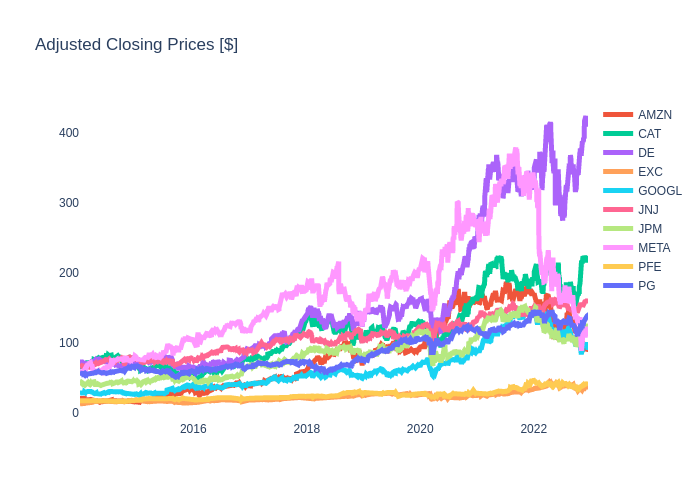

In [ ]:
# Plot closing prices using plotly Express. Note that we used the same pre-defined function "plot_financial_data"
plot_financial_data(close_price_df, 'Adjusted Closing Prices [$]')

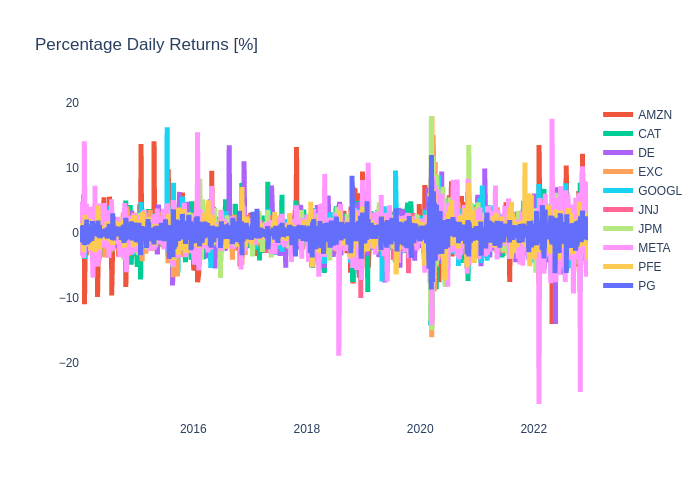

In [ ]:
# Plot the stocks daily returns
plot_financial_data(daily_returns_df, 'Percentage Daily Returns [%]')

In [ ]:
# Plot histograms for stocks daily returns using plotly express
# Compare META to JNJ daily returns histograms
fig = px.histogram(daily_returns_df.drop(columns = ['Date']))
fig.update_layout({'plot_bgcolor': "white"})

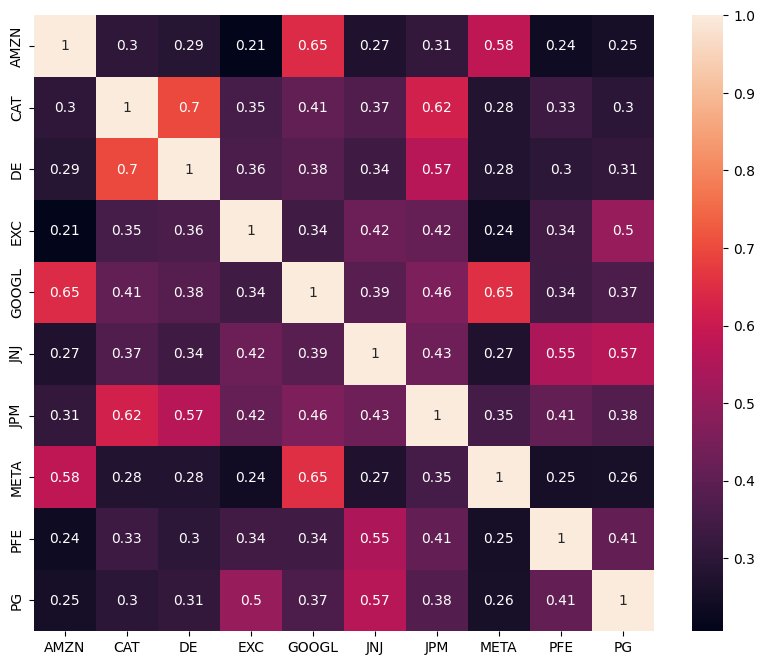

In [ ]:
# Plot a heatmap showing the correlations between daily returns
# Strong positive correlations between Catterpillar and John Deere - both into heavy equipment and machinery
# META and Google - both into Tech and Cloud Computing
plt.figure(figsize = (10, 8))
sns.heatmap(daily_returns_df.drop(columns = ['Date']).corr(), annot = True);

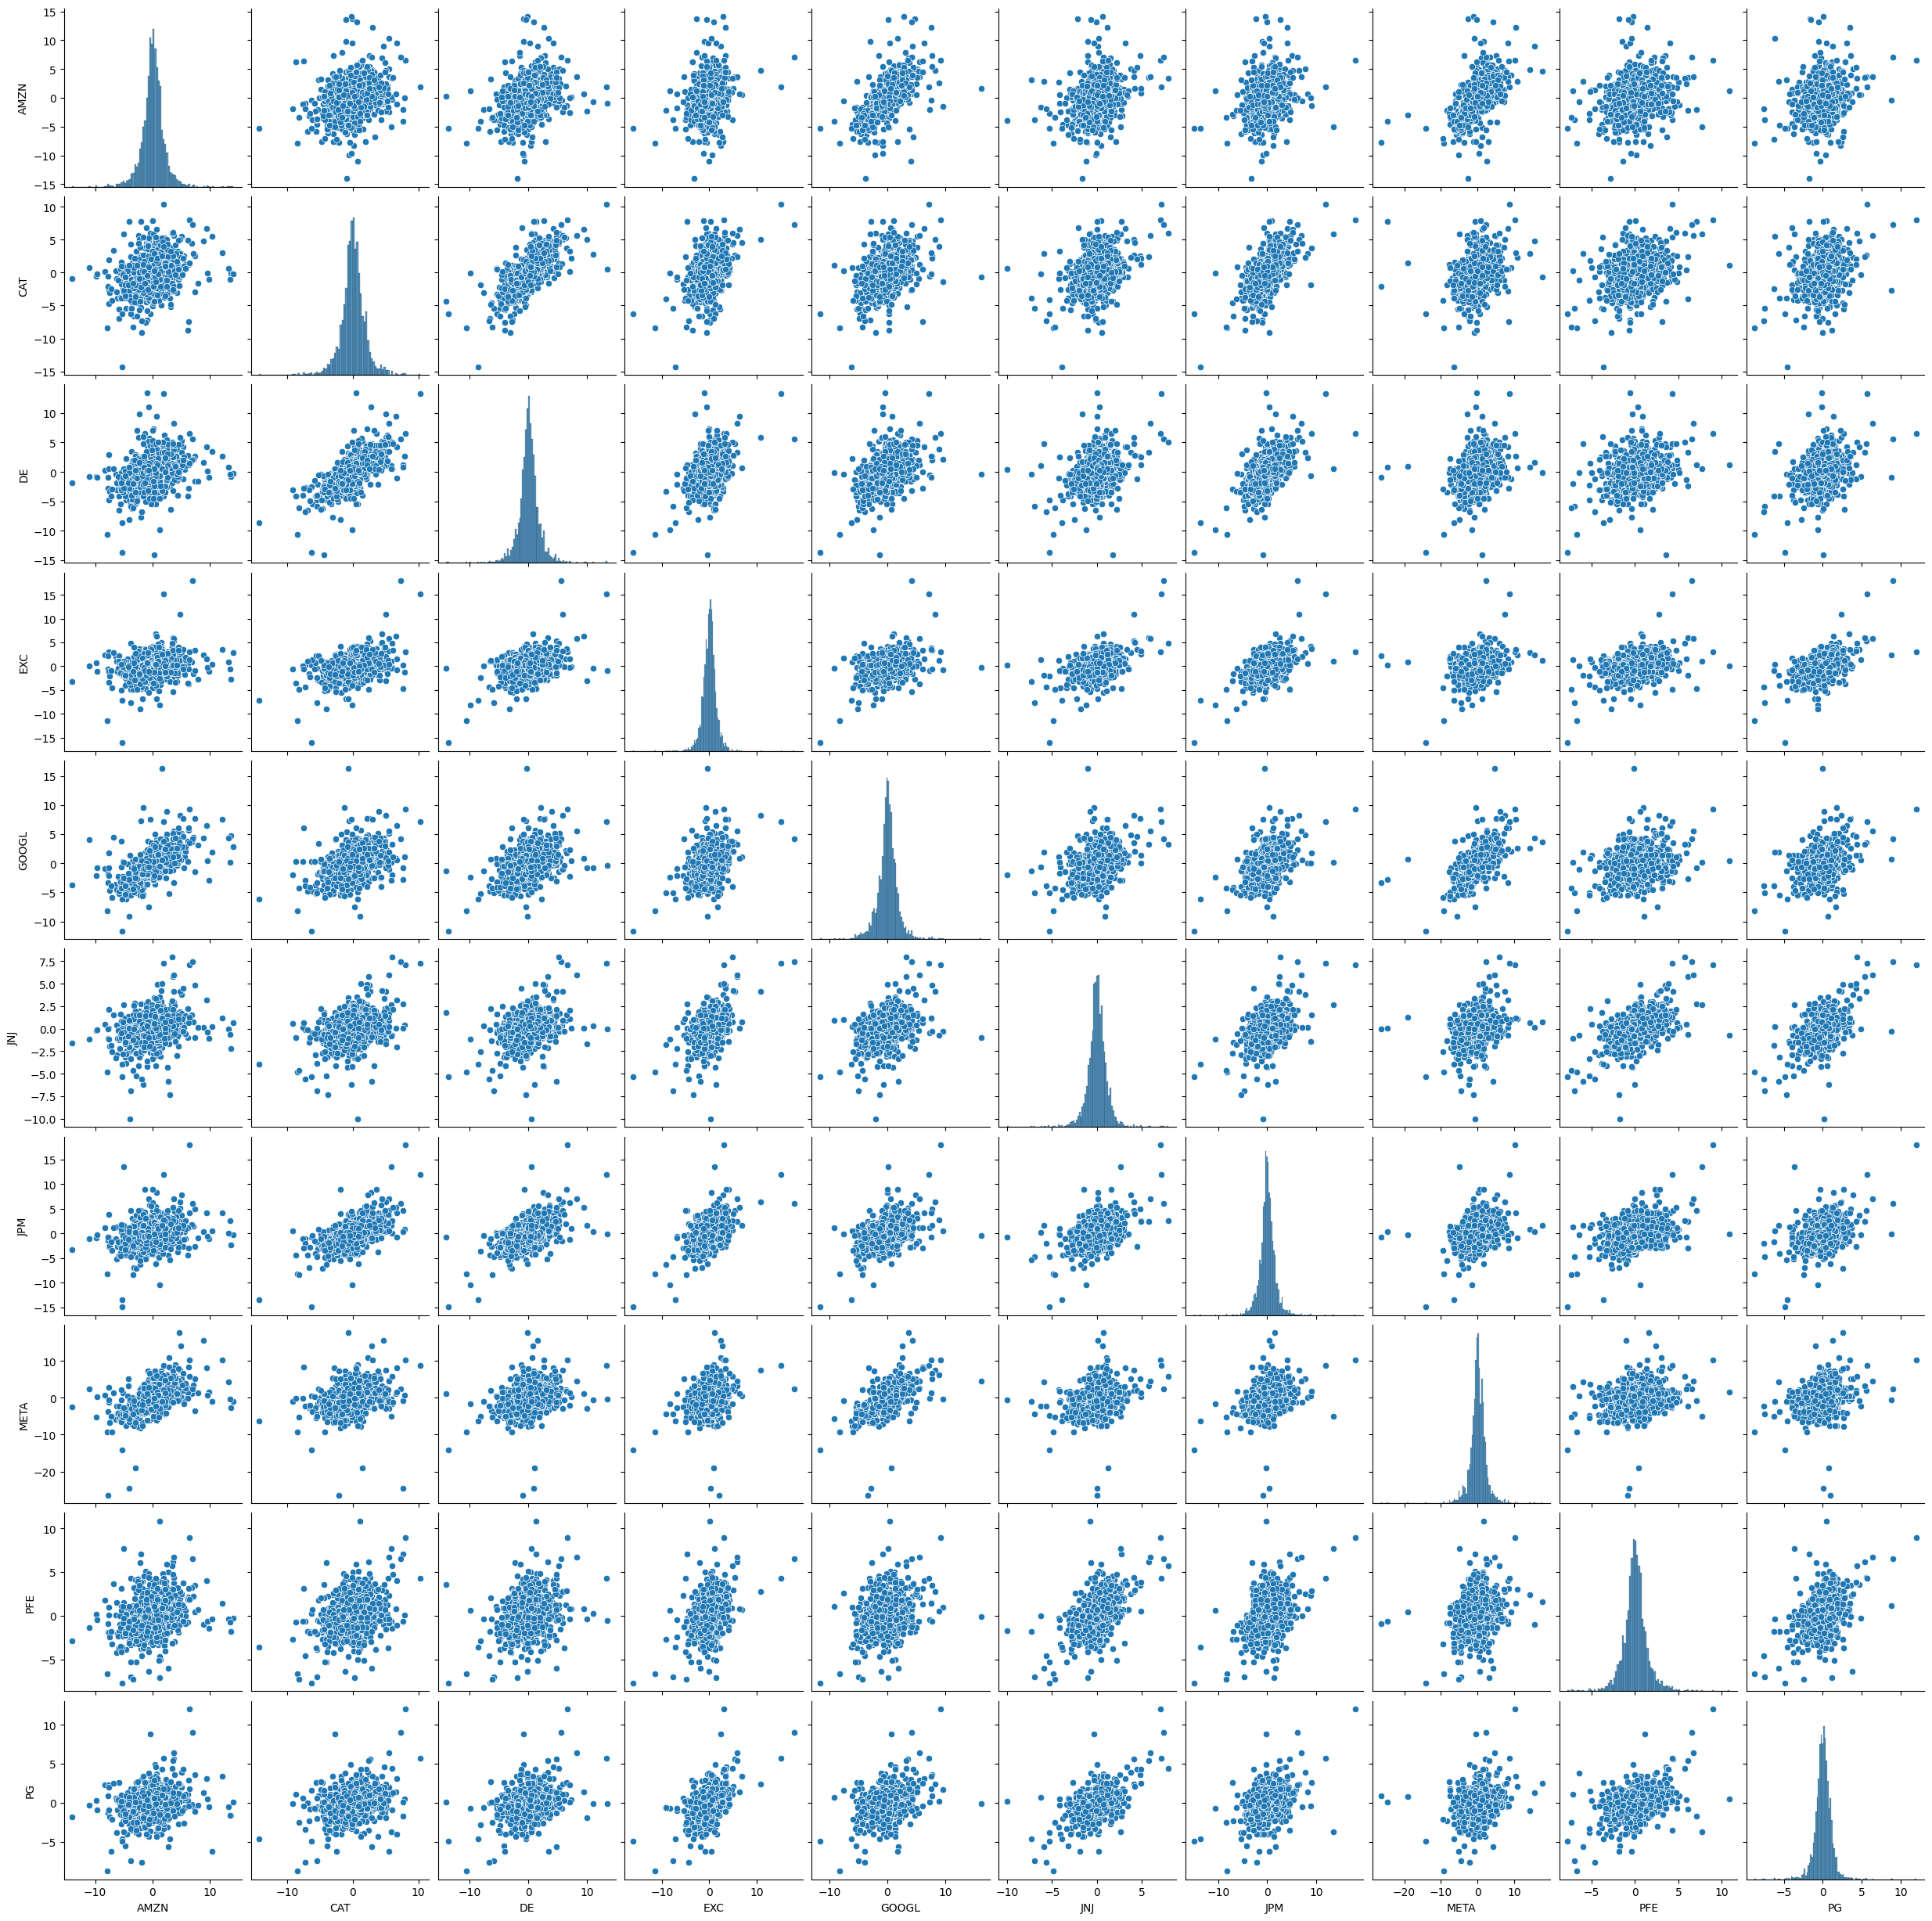

In [ ]:
# Plot the Pairplot between stocks daily returns
sns.pairplot(daily_returns_df);

## Random weights generation, asset allocation & portfolio simulation

In [ ]:
# Function to scale stock prices based on their initial starting price
# The objective of this function is to set all prices to start at a value of 1
def price_scaling(raw_prices_df):
    scaled_prices_df = raw_prices_df.copy()
    for i in raw_prices_df.columns[1:]:
        scaled_prices_df[i] = raw_prices_df[i]/raw_prices_df[i][0]
    return scaled_prices_df

In [ ]:
price_scaling(close_price_df)

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,2014-01-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2014-01-03,0.996155,0.999443,1.004432,0.979757,0.992705,1.009007,1.007731,0.997258,1.001970,0.998883
2,2014-01-06,0.989095,0.986313,0.996123,0.986014,1.003773,1.014281,1.013571,1.045513,1.002955,1.001242
3,2014-01-07,1.000151,0.989540,1.000555,0.991166,1.023124,1.035812,1.001890,1.058673,1.009193,1.010927
4,2014-01-08,1.009925,0.991877,0.989808,0.988958,1.025253,1.034384,1.011339,1.064339,1.016087,0.996275
...,...,...,...,...,...,...,...,...,...,...,...
2252,2022-12-12,4.550594,3.352775,5.779488,3.009701,3.349744,2.489245,2.940618,2.096692,2.498198,2.461515
2253,2022-12-13,4.648089,3.387734,5.781339,3.012534,3.433030,2.508422,2.937769,2.196125,2.541783,2.457803
2254,2022-12-14,4.602357,3.373204,5.797869,3.032362,3.412927,2.516120,2.923089,2.222445,2.609314,2.467489
2255,2022-12-15,4.445058,3.318249,5.683483,3.001202,3.261792,2.484347,2.850566,2.123012,2.567646,2.439560


In [ ]:
# Let's create an array that holds random portfolio weights
# Note that portfolio weights must add up to 1
import random

def generate_portfolio_weights(n):
    weights = []
    for i in range(n):
        weights.append(random.random())

    # Let's make the sum of all weights add up to 1
    weights = weights/np.sum(weights)
    return weights

In [ ]:
# Call the function (Run this cell multiple times to generate different outputs)
weights = generate_portfolio_weights(4)
print(weights)

[0.0592358  0.41622144 0.2941693  0.23037345]


In [ ]:
# Let's define the "weights" list similar to the slides
weights = [0.032266, 0.094461, 0.117917, 0.132624, 0.145942, 0.128299, 0.10009, 0.007403, 0.088581, 0.152417]
weights

[0.032266,
 0.094461,
 0.117917,
 0.132624,
 0.145942,
 0.128299,
 0.10009,
 0.007403,
 0.088581,
 0.152417]

In [ ]:
# Let's display "close_price_df" Pandas DataFrame
close_price_df

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,2014-01-02,19.898500,65.644272,71.915642,12.284677,27.593288,64.182755,41.794571,54.233742,16.690779,56.173172
1,2014-01-03,19.822001,65.607735,72.234375,12.035998,27.391998,64.760872,42.117672,54.085052,16.723660,56.110413
2,2014-01-06,19.681499,64.745827,71.636795,12.112864,27.697399,65.099342,42.361786,56.702065,16.740099,56.242928
3,2014-01-07,19.901501,64.957626,71.955521,12.176160,28.231358,66.481270,41.873547,57.415794,16.844212,56.786964
4,2014-01-08,20.096001,65.111023,71.182648,12.149035,28.290108,66.389626,42.268459,57.723095,16.959278,55.963943
...,...,...,...,...,...,...,...,...,...,...,...
2252,2022-12-12,90.550003,220.090469,415.635559,36.973209,92.430450,159.766632,122.901878,113.711441,41.696865,138.271133
2253,2022-12-13,92.489998,222.385300,415.768707,37.008007,94.728577,160.997406,122.782806,119.104088,42.424332,138.062576
2254,2022-12-14,91.580002,221.431488,416.957458,37.251591,94.173866,161.491501,122.169266,120.531525,43.551479,138.606674
2255,2022-12-15,88.449997,217.824066,408.731354,36.868801,90.003555,159.452240,119.138184,115.138908,42.856007,137.037811


In [ ]:
# Scale stock prices using the "price_scaling" function that we defined earlier (make all stock values start at 1)
portfolio_df = close_price_df.copy()
scaled_df = price_scaling(portfolio_df)
scaled_df

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,2014-01-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2014-01-03,0.996155,0.999443,1.004432,0.979757,0.992705,1.009007,1.007731,0.997258,1.001970,0.998883
2,2014-01-06,0.989095,0.986313,0.996123,0.986014,1.003773,1.014281,1.013571,1.045513,1.002955,1.001242
3,2014-01-07,1.000151,0.989540,1.000555,0.991166,1.023124,1.035812,1.001890,1.058673,1.009193,1.010927
4,2014-01-08,1.009925,0.991877,0.989808,0.988958,1.025253,1.034384,1.011339,1.064339,1.016087,0.996275
...,...,...,...,...,...,...,...,...,...,...,...
2252,2022-12-12,4.550594,3.352775,5.779488,3.009701,3.349744,2.489245,2.940618,2.096692,2.498198,2.461515
2253,2022-12-13,4.648089,3.387734,5.781339,3.012534,3.433030,2.508422,2.937769,2.196125,2.541783,2.457803
2254,2022-12-14,4.602357,3.373204,5.797869,3.032362,3.412927,2.516120,2.923089,2.222445,2.609314,2.467489
2255,2022-12-15,4.445058,3.318249,5.683483,3.001202,3.261792,2.484347,2.850566,2.123012,2.567646,2.439560


In [ ]:
# Use enumerate() method to obtain the stock names along with a counter "i" (0, 1, 2, 3,..etc.)
# This counter "i" will be used as an index to access elements in the "weights" list
initial_investment = 1000000
for i, stock in enumerate(scaled_df.columns[1:]):
    portfolio_df[stock] = weights[i] * scaled_df[stock]  * initial_investment
portfolio_df.round(1)

,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG
0,2014-01-02,32266.0,94461.0,117917.0,132624.0,145942.0,128299.0,100090.0,7403.0,88581.0,152417.0
1,2014-01-03,32142.0,94408.4,118439.6,129939.3,144877.4,129454.6,100863.8,7382.7,88755.5,152246.7
2,2014-01-06,31914.1,93168.2,117459.8,130769.1,146492.6,130131.2,101448.4,7739.9,88842.8,152606.3
3,2014-01-07,32270.9,93472.9,117982.4,131452.5,149316.8,132893.6,100279.1,7837.4,89395.3,154082.4
4,2014-01-08,32586.3,93693.7,116715.1,131159.6,149627.5,132710.5,101224.9,7879.3,90006.0,151849.3
...,...,...,...,...,...,...,...,...,...,...,...
2252,2022-12-12,146829.5,316706.5,681499.8,399158.7,488868.3,319367.7,294326.5,15521.8,221292.9,375176.8
2253,2022-12-13,149975.2,320008.7,681718.2,399534.3,501023.2,321828.0,294041.3,16257.9,225153.6,374610.9
2254,2022-12-14,148499.6,318636.2,683667.3,402164.0,498089.3,322815.7,292572.0,16452.8,231135.6,376087.2
2255,2022-12-15,143424.3,313445.2,670179.3,398031.5,476032.4,318739.2,285313.2,15716.7,227444.6,371830.4


In [ ]:
# Assume that we have $1,000,000 that we would like to invest in one or more of the selected stocks
# Let's create a function that receives the following arguments:
    # (1) Stocks closing prices
    # (2) Random weights
    # (3) Initial investment amount
# The function will return a DataFrame that contains the following:
    # (1) Daily value (position) of each individual stock over the specified time period
    # (2) Total daily value of the portfolio
    # (3) Percentage daily return

def asset_allocation(df, weights, initial_investment):
    portfolio_df = df.copy()

    # Scale stock prices using the "price_scaling" function that we defined earlier (Make them all start at 1)
    scaled_df = price_scaling(df)

    for i, stock in enumerate(scaled_df.columns[1:]):
        portfolio_df[stock] = scaled_df[stock] * weights[i] * initial_investment

    # Sum up all values and place the result in a new column titled "portfolio value [$]"
    # Note that we excluded the date column from this calculation
    portfolio_df['Portfolio Value [$]'] = portfolio_df[portfolio_df != 'Date'].sum(axis = 1, numeric_only = True)

    # Calculate the portfolio percentage daily return and replace NaNs with zeros
    portfolio_df['Portfolio Daily Return [%]'] = portfolio_df['Portfolio Value [$]'].pct_change(1) * 100
    portfolio_df.replace(np.nan, 0, inplace = True)

    return portfolio_df

In [ ]:
# Now Let's put this code in a function and generate random weights
# Let's obtain the number of stocks under consideration (note that we ignored the "Date" column)
n = len(close_price_df.columns)-1

# Let's generate random weights
print('Number of stocks under consideration = {}'.format(n))
weights = generate_portfolio_weights(n).round(6)
print('Portfolio weights = {}'.format(weights))

# Let's test out the "asset_allocation" function
portfolio_df = asset_allocation(close_price_df, weights, 1000000)
portfolio_df.round(2)

Number of stocks under consideration = 10
Portfolio weights = [0.165486 0.143724 0.110706 0.099344 0.04065  0.095872 0.131841 0.026491
 0.119611 0.066276]


,Date,AMZN,CAT,DE,EXC,GOOGL,JNJ,JPM,META,PFE,PG,Portfolio Value [$],Portfolio Daily Return [%]
0,2014-01-02,165486.00,143724.00,110706.00,99344.00,40650.00,95872.00,131841.00,26491.00,119611.00,66276.00,1000001.00,0.00
1,2014-01-03,164849.79,143644.00,111196.65,97332.98,40353.46,96735.55,132860.22,26418.37,119846.63,66201.95,999439.63,-0.06
2,2014-01-06,163681.31,141756.91,110276.75,97954.58,40803.37,97241.14,133630.28,27696.68,119964.44,66358.30,999363.76,-0.01
3,2014-01-07,165510.95,142220.63,110767.39,98466.44,41589.99,99305.37,132090.13,28045.30,120710.54,67000.18,1005706.95,0.63
4,2014-01-08,167128.51,142556.49,109577.64,98247.09,41676.54,99168.48,133335.88,28195.41,121535.15,66029.14,1007450.32,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2252,2022-12-12,753059.65,481874.22,639823.95,298995.79,136167.09,238648.94,387694.05,55543.46,298811.93,163139.40,3453758.49,1.41
2253,2022-12-13,769193.63,486898.61,640028.92,299277.19,139552.65,240487.39,387318.44,58177.55,304025.16,162893.33,3487852.89,0.99
2254,2022-12-14,761625.64,484810.30,641858.87,301247.01,138735.46,241225.44,385383.02,58874.80,312102.63,163535.29,3489398.47,0.04
2255,2022-12-15,735594.94,476912.08,629195.71,298151.45,132591.83,238179.33,375821.47,56240.72,307118.67,161684.26,3411490.46,-2.23


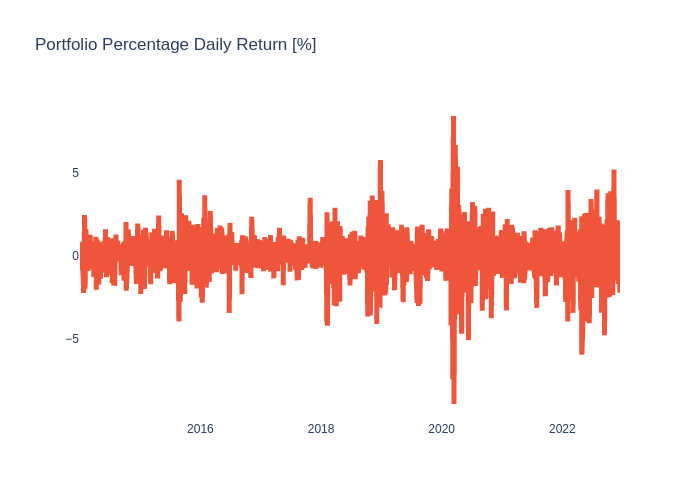

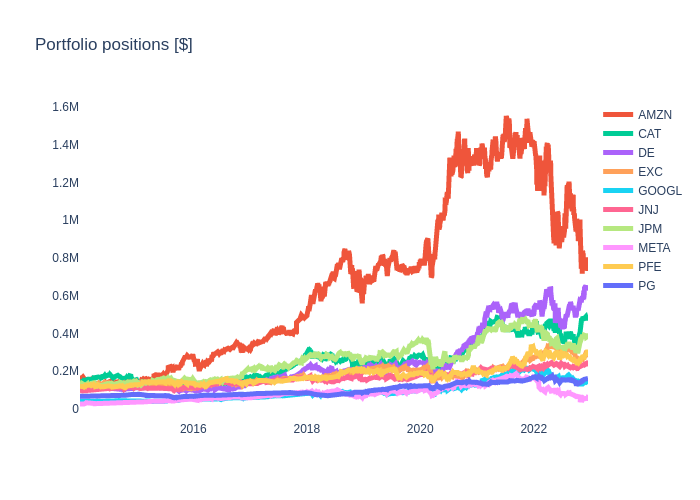

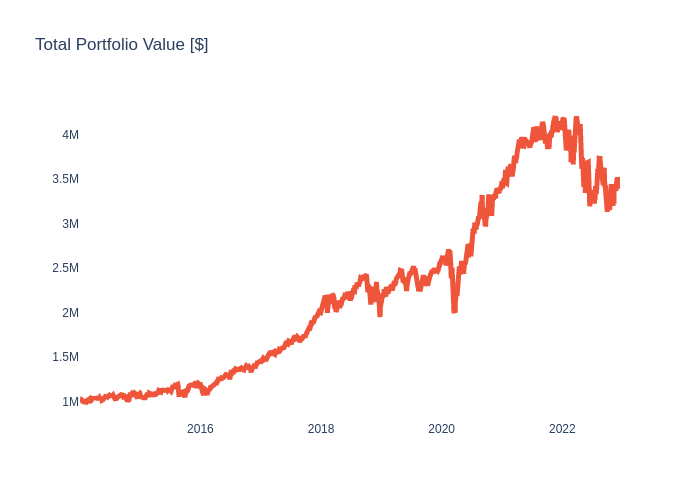

In [ ]:
# Plot the portfolio percentage daily return
plot_financial_data(portfolio_df[['Date', 'Portfolio Daily Return [%]']], 'Portfolio Percentage Daily Return [%]')

# Plot each stock position in our portfolio over time
# This graph shows how our initial investment in each individual stock grows over time
plot_financial_data(portfolio_df.drop(['Portfolio Value [$]', 'Portfolio Daily Return [%]'], axis = 1), 'Portfolio positions [$]')

# Plot the total daily value of the portfolio (sum of all positions)
plot_financial_data(portfolio_df[['Date', 'Portfolio Value [$]']], 'Total Portfolio Value [$]')

## Run Monte Carlo simulations

In [ ]:
# Let's define the simulation engine function
# The function receives:
    # (1) portfolio weights
    # (2) initial investment amount
# The function performs asset allocation and calculates portfolio statistical metrics including Sharpe ratio
# The function returns:
    # (1) Expected portfolio return
    # (2) Expected volatility
    # (3) Sharpe ratio
    # (4) Return on investment
    # (5) Final portfolio value in dollars

def simulation_engine(weights, initial_investment):
    # Perform asset allocation using the random weights (sent as arguments to the function)
    portfolio_df = asset_allocation(close_price_df, weights, initial_investment)

    # Calculate the return on the investment
    # Return on investment is calculated using the last final value of the portfolio compared to its initial value
    return_on_investment = ((portfolio_df['Portfolio Value [$]'].iloc[-1] -
                              portfolio_df['Portfolio Value [$]'].iloc[0])/
                              portfolio_df['Portfolio Value [$]'].iloc[0]) * 100

    # Daily change of every stock in the portfolio (Note that we dropped the date, portfolio daily worth and daily % returns)
    portfolio_daily_return_df = portfolio_df.drop(columns = ['Date', 'Portfolio Value [$]', 'Portfolio Daily Return [%]'])
    portfolio_daily_return_df = portfolio_daily_return_df.pct_change(1)

    # Portfolio Expected Return formula
    expected_portfolio_return = np.sum(weights * portfolio_daily_return_df.mean() ) * 252

    # Portfolio volatility (risk) formula
    # The risk of an asset is measured using the standard deviation which indicates the dispertion away from the mean
    # The risk of a portfolio is not a simple sum of the risks of the individual assets within the portfolio
    # Portfolio risk must consider correlations between assets within the portfolio which is indicated by the covariance
    # The covariance determines the relationship between the movements of two random variables
    # when two stocks move together, they have a positive covariance when they move inversely, the have a negative covariance

    covariance = portfolio_daily_return_df.cov() * 252
    expected_volatility = np.sqrt(np.dot(weights.T, np.dot(covariance, weights)))

    # Check out the chart for the 10-years U.S. treasury at https://ycharts.com/indicators/10_year_treasury_rate
    rf = 0.03 # Try to set the risk free rate of return to 1% (assumption)

    # Calculate Sharpe ratio
    sharpe_ratio = (expected_portfolio_return - rf)/expected_volatility
    return expected_portfolio_return, expected_volatility, sharpe_ratio, portfolio_df['Portfolio Value [$]'][-1:].values[0], return_on_investment

In [ ]:
# Let's test out the "simulation_engine" function and print out statistical metrics
# Define the initial investment amount
initial_investment = 1000000
portfolio_metrics = simulation_engine(weights, initial_investment)

In [ ]:
print('Expected Portfolio Annual Return = {:.2f}%'.format(portfolio_metrics[0] * 100))
print('Portfolio Standard Deviation (Volatility) = {:.2f}%'.format(portfolio_metrics[1] * 100))
print('Sharpe Ratio = {:.2f}'.format(portfolio_metrics[2]))
print('Portfolio Final Value = ${:.2f}'.format(portfolio_metrics[3]))
print('Return on Investment = {:.2f}%'.format(portfolio_metrics[4]))

Expected Portfolio Annual Return = 16.90%
Portfolio Standard Deviation (Volatility) = 18.22%
Sharpe Ratio = 0.76
Portfolio Final Value = $3392133.18
Return on Investment = 239.21%


In [ ]:
# Set the number of simulation runs
sim_runs = 10000
initial_investment = 1000000

# Placeholder to store all weights
weights_runs = np.zeros((sim_runs, n))

# Placeholder to store all Sharpe ratios
sharpe_ratio_runs = np.zeros(sim_runs)

# Placeholder to store all expected returns
expected_portfolio_returns_runs = np.zeros(sim_runs)

# Placeholder to store all volatility values
volatility_runs = np.zeros(sim_runs)

# Placeholder to store all returns on investment
return_on_investment_runs = np.zeros(sim_runs)

# Placeholder to store all final portfolio values
final_value_runs = np.zeros(sim_runs)

for i in range(sim_runs):
    # Generate random weights
    weights = generate_portfolio_weights(n)
    # Store the weights
    weights_runs[i,:] = weights

    # Call "simulation_engine" function and store Sharpe ratio, return and volatility
    # Note that asset allocation is performed using the "asset_allocation" function
    expected_portfolio_returns_runs[i], volatility_runs[i], sharpe_ratio_runs[i], final_value_runs[i], return_on_investment_runs[i] = simulation_engine(weights, initial_investment)
    print("Simulation Run = {}".format(i))
    print("Weights = {}, Final Value = ${:.2f}, Sharpe Ratio = {:.2f}".format(weights_runs[i].round(3), final_value_runs[i], sharpe_ratio_runs[i]))
    print('\n')

Se han truncado las últimas 5000 líneas del flujo de salida.
Simulation Run = 8750
Weights = [0.132 0.133 0.067 0.112 0.107 0.141 0.099 0.155 0.041 0.013], Final Value = $3185962.48, Sharpe Ratio = 0.71


Simulation Run = 8751
Weights = [0.046 0.158 0.119 0.027 0.196 0.084 0.108 0.084 0.14  0.036], Final Value = $3259683.51, Sharpe Ratio = 0.71


Simulation Run = 8752
Weights = [0.123 0.034 0.078 0.102 0.085 0.163 0.047 0.071 0.131 0.166], Final Value = $3094938.71, Sharpe Ratio = 0.75


Simulation Run = 8753
Weights = [0.107 0.022 0.086 0.062 0.135 0.118 0.005 0.184 0.119 0.162], Final Value = $3050918.34, Sharpe Ratio = 0.69


Simulation Run = 8754
Weights = [0.178 0.047 0.147 0.16  0.05  0.054 0.107 0.132 0.006 0.121], Final Value = $3446052.07, Sharpe Ratio = 0.75


Simulation Run = 8755
Weights = [0.193 0.085 0.109 0.026 0.101 0.049 0.184 0.028 0.172 0.054], Final Value = $3417026.14, Sharpe Ratio = 0.74


Simulation Run = 8756
Weights = [0.182 0.122 0.196 0.121 0.03  0.1   0.018 

In [ ]:
# List all Sharpe ratios generated from the simulation
sharpe_ratio_runs

array([0.74504736, 0.66297194, 0.70315764, ..., 0.75092841, 0.75659747,
       0.73827149])

In [ ]:
# Return the index of the maximum Sharpe ratio (Best simulation run)
sharpe_ratio_runs.argmax()

4183

In [ ]:
# Return the maximum Sharpe ratio value
sharpe_ratio_runs.max()

0.8156717008243576

In [ ]:
weights_runs

array([[0.18307828, 0.14923745, 0.07198747, ..., 0.09432249, 0.12909199,
        0.11002415],
       [0.00830376, 0.12592219, 0.06091213, ..., 0.17397785, 0.1702692 ,
        0.0893004 ],
       [0.23850206, 0.04378125, 0.02630411, ..., 0.06220232, 0.03659963,
        0.03139039],
       ...,
       [0.13069709, 0.06043106, 0.08519619, ..., 0.04654367, 0.08489614,
        0.16457831],
       [0.06521164, 0.16313836, 0.140361  , ..., 0.01731928, 0.17623391,
        0.09460877],
       [0.10557604, 0.17980162, 0.14486305, ..., 0.08399558, 0.05747513,
        0.00454964]])

In [ ]:
# Obtain the portfolio weights that correspond to the maximum Sharpe ratio (Golden set of weights!)
weights_runs[sharpe_ratio_runs.argmax(), :]

array([0.15272595, 0.06390791, 0.2745626 , 0.21787861, 0.05559023,
       0.02058256, 0.01652191, 0.03319644, 0.08444588, 0.08058792])

In [ ]:
# Return Sharpe ratio, volatility corresponding to the best weights allocation (maximum Sharpe ratio)
optimal_portfolio_return, optimal_volatility, optimal_sharpe_ratio, highest_final_value, optimal_return_on_investment = simulation_engine(weights_runs[sharpe_ratio_runs.argmax()], initial_investment)

In [ ]:
print('Best Portfolio Metrics Based on {} Monte Carlo Simulation Runs:'.format(sim_runs))
print('  - Portfolio Expected Annual Return = {:.02f}%'.format(optimal_portfolio_return * 100))
print('  - Portfolio Standard Deviation (Volatility) = {:.02f}%'.format(optimal_volatility * 100))
print('  - Sharpe Ratio = {:.02f}'.format(optimal_sharpe_ratio))
print('  - Final Value = ${:.02f}'.format(highest_final_value))
print('  - Return on Investment = {:.02f}%'.format(optimal_return_on_investment))

Best Portfolio Metrics Based on 10000 Monte Carlo Simulation Runs:
  - Portfolio Expected Annual Return = 18.32%
  - Portfolio Standard Deviation (Volatility) = 18.78%
  - Sharpe Ratio = 0.82
  - Final Value = $3854072.76
  - Return on Investment = 285.41%


In [ ]:
# Create a DataFrame that contains volatility, return, and Sharpe ratio for all simulation runs
sim_out_df = pd.DataFrame({'Volatility': volatility_runs.tolist(), 'Portfolio_Return': expected_portfolio_returns_runs.tolist(), 'Sharpe_Ratio': sharpe_ratio_runs.tolist()})
sim_out_df

,Volatility,Portfolio_Return,Sharpe_Ratio
0,0.179999,0.164108,0.745047
1,0.184378,0.152237,0.662972
2,0.193465,0.166036,0.703158
3,0.193727,0.178244,0.765219
4,0.185408,0.160310,0.702830
...,...,...,...
9995,0.181942,0.167878,0.757812
9996,0.170504,0.152881,0.720695
9997,0.171740,0.158965,0.750928
9998,0.179526,0.165829,0.756597


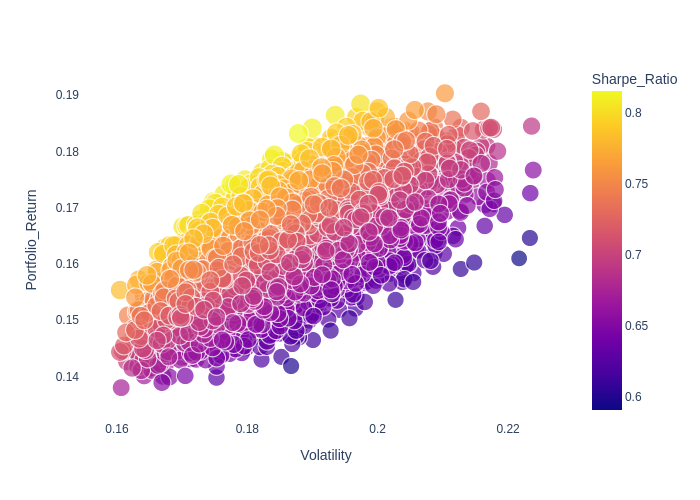

In [ ]:
# Plot volatility vs. return for all simulation runs
# Highlight the volatility and return that corresponds to the highest Sharpe ratio
import plotly.graph_objects as go
fig = px.scatter(sim_out_df, x = 'Volatility', y = 'Portfolio_Return', color = 'Sharpe_Ratio', size = 'Sharpe_Ratio', hover_data = ['Sharpe_Ratio'] )
fig.update_layout({'plot_bgcolor': "white"})
fig.show()

# Use this code if Sharpe ratio is negative
# fig = px.scatter(sim_out_df, x = 'Volatility', y = 'Portfolio_Return', color = 'Sharpe_Ratio', hover_data = ['Sharpe_Ratio'] )

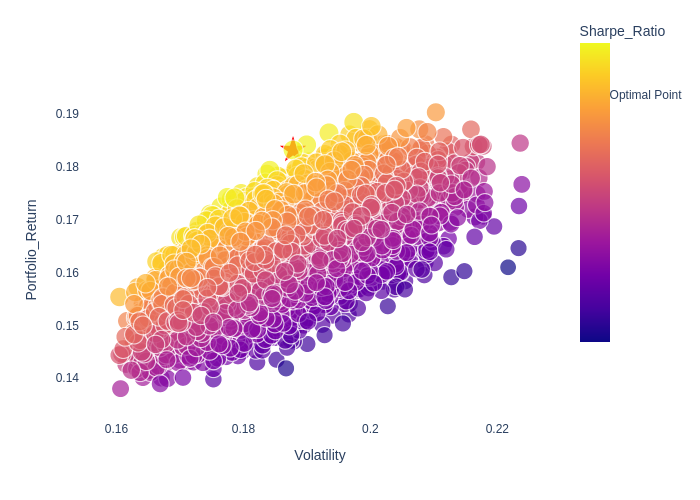

In [ ]:
# Let's highlight the point with the highest Sharpe ratio
fig = px.scatter(sim_out_df, x = 'Volatility', y = 'Portfolio_Return', color = 'Sharpe_Ratio', size = 'Sharpe_Ratio', hover_data = ['Sharpe_Ratio'])
fig.add_trace(go.Scatter(x = [optimal_volatility], y = [optimal_portfolio_return], mode = 'markers', name = 'Optimal Point',
                          marker = dict(size = 20, color = 'red', symbol = 'star')))
fig.update_layout(coloraxis_colorbar = dict(y = 0.7, dtick = 5))
fig.update_layout({'plot_bgcolor': "white"})
fig.show()

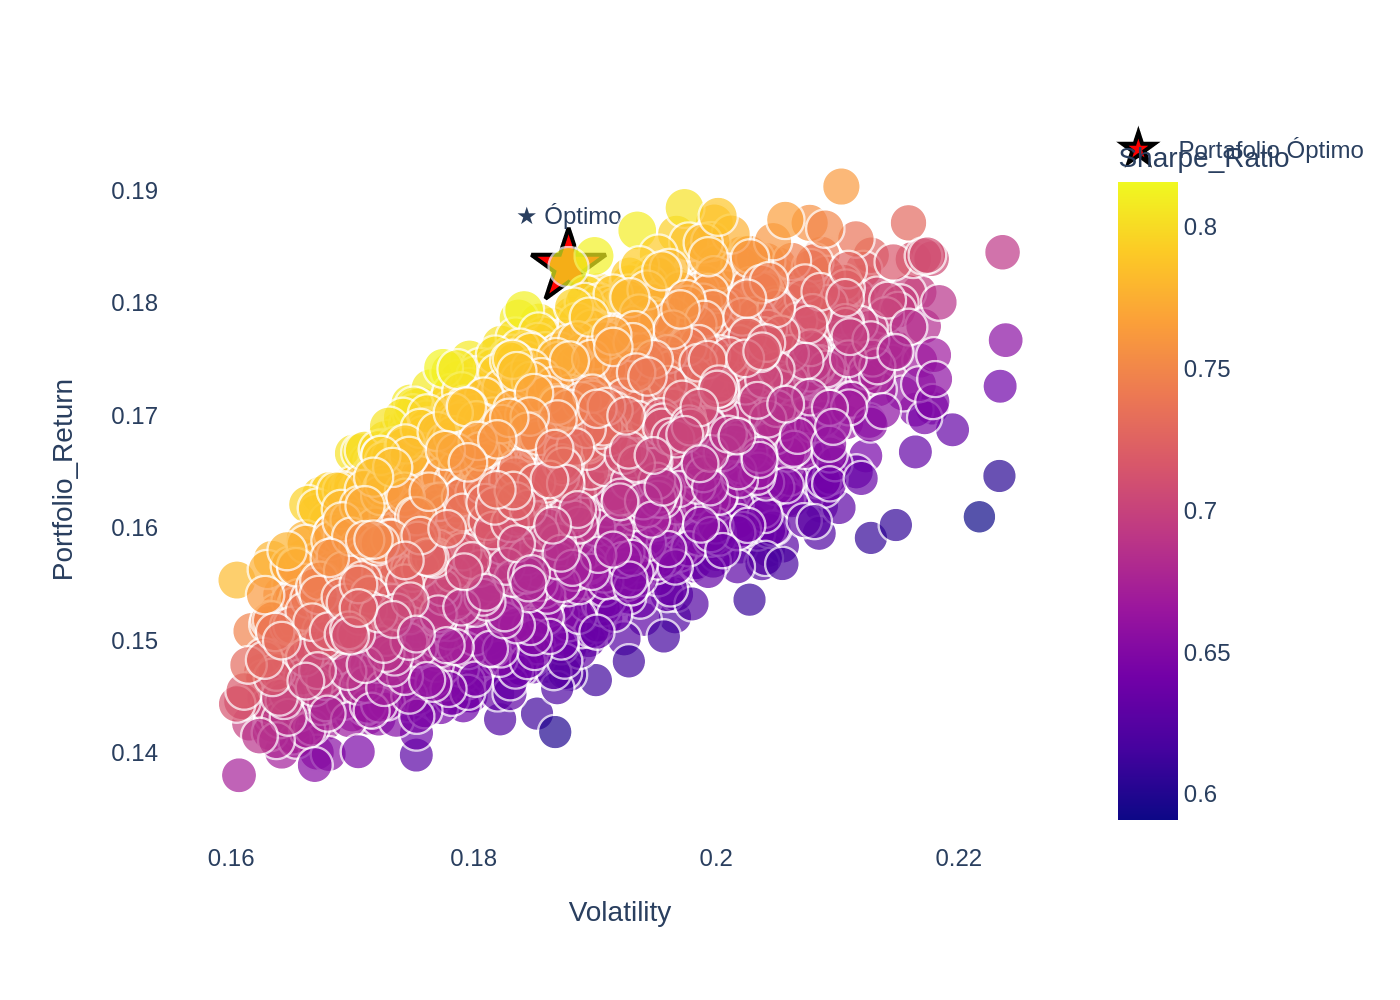

PORTAFOLIO ÓPTIMO — Frontera Eficiente (Monte Carlo)
Periodo analizado:            2014-01-02 a 2022-12-16
Retorno anual esperado:       18.32%
Volatilidad (riesgo):         18.78%
Sharpe Ratio:                 0.82
Inversión inicial:            $1,000,000.00
Valor final del portafolio:   $3,854,072.76
Retorno sobre la inversión:   285.41%

Distribución de pesos por acción:
  AMZN     15.27%   $152,725.95
  CAT       6.39%   $63,907.91
  DE       27.46%   $274,562.60
  EXC      21.79%   $217,878.61
  GOOGL     5.56%   $55,590.23
  JNJ       2.06%   $20,582.56
  JPM       1.65%   $16,521.91
  META      3.32%   $33,196.44
  PFE       8.44%   $84,445.88
  PG        8.06%   $80,587.92


In [ ]:
!pip install -q "kaleido==0.2.1"
from IPython.display import Image, display
import plotly.express as px
import plotly.graph_objects as go

optimal_weights = weights_runs[sharpe_ratio_runs.argmax()]
tickers = close_price_df.columns[1:]

# --- Gráfica con el punto óptimo bien visible ---
fig = px.scatter(sim_out_df, x='Volatility', y='Portfolio_Return', color='Sharpe_Ratio', size='Sharpe_Ratio')
fig.add_trace(go.Scatter(
    x=[optimal_volatility], y=[optimal_portfolio_return],
    mode='markers+text',
    name='Portafolio Óptimo',
    text=['★ Óptimo'],
    textposition='top center',
    marker=dict(size=28, color='red', symbol='star', line=dict(width=2, color='black'))
))
fig.update_layout({'plot_bgcolor': "white"})
fig.write_image('frontera_eficiente.png', engine='kaleido', scale=2)
display(Image('frontera_eficiente.png'))

# --- Resumen del portafolio óptimo ---
fecha_inicio = close_price_df['Date'].min()
fecha_fin = close_price_df['Date'].max()

print("="*60)
print("PORTAFOLIO ÓPTIMO — Frontera Eficiente (Monte Carlo)")
print("="*60)
print(f"Periodo analizado:            {fecha_inicio} a {fecha_fin}")
print(f"Retorno anual esperado:       {optimal_portfolio_return*100:.2f}%")
print(f"Volatilidad (riesgo):         {optimal_volatility*100:.2f}%")
print(f"Sharpe Ratio:                 {optimal_sharpe_ratio:.2f}")
print(f"Inversión inicial:            ${initial_investment:,.2f}")
print(f"Valor final del portafolio:   ${highest_final_value:,.2f}")
print(f"Retorno sobre la inversión:   {optimal_return_on_investment:.2f}%")
print()
print("Distribución de pesos por acción:")
for ticker, w in zip(tickers, optimal_weights):
    monto = w * initial_investment
    print(f"  {ticker:6s}  {w*100:6.2f}%   ${monto:,.2f}")


## Practice opportunity solution — JPMorgan Chase & Co. (JPM)

In [ ]:
# Use Pandas to read stock data (the csv file is included in the course package)
JPM_df = pd.read_csv('JPM.csv')
JPM_df

,Date,Open,High,Low,Close,Volume,Adj Close
0,2017-07-14,90.809998,92.610001,90.580002,92.250000,22235200,72.654068
1,2017-07-17,91.820000,91.989998,91.250000,91.389999,14374200,71.976768
2,2017-07-18,90.449997,91.580002,90.320000,91.070000,14719400,71.724754
3,2017-07-19,91.339996,91.620003,91.000000,91.199997,11651200,71.827133
4,2017-07-20,91.150002,91.720001,90.900002,91.199997,11561700,71.827133
...,...,...,...,...,...,...,...
1363,2022-12-12,132.399994,134.649994,131.600006,134.210007,8841600,122.901871
1364,2022-12-13,136.889999,137.089996,133.080002,134.080002,10025400,122.782806
1365,2022-12-14,133.779999,135.710007,132.759995,133.410004,9966100,122.169281
1366,2022-12-15,131.149994,132.080002,129.050003,130.100006,12087800,119.138176


In [ ]:
JPM_df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Adj Close,0


In [ ]:
JPM_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1368 entries, 0 to 1367
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1368 non-null   object 
 1   Open       1368 non-null   float64
 2   High       1368 non-null   float64
 3   Low        1368 non-null   float64
 4   Close      1368 non-null   float64
 5   Volume     1368 non-null   int64  
 6   Adj Close  1368 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 74.9+ KB


In [ ]:
# Calculate the percentage daily return
# Note that we had to replace the first row with zeros instead of NaN
JPM_df['Daily Return'] = JPM_df['Adj Close'].pct_change(1) * 100
JPM_df['Daily Return'].replace(np.nan, 0, inplace = True)
JPM_df

/tmp/ipykernel_499/2921983930.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return
0,2017-07-14,90.809998,92.610001,90.580002,92.250000,22235200,72.654068,0.000000
1,2017-07-17,91.820000,91.989998,91.250000,91.389999,14374200,71.976768,-0.932225
2,2017-07-18,90.449997,91.580002,90.320000,91.070000,14719400,71.724754,-0.350133
3,2017-07-19,91.339996,91.620003,91.000000,91.199997,11651200,71.827133,0.142739
4,2017-07-20,91.150002,91.720001,90.900002,91.199997,11561700,71.827133,0.000000
...,...,...,...,...,...,...,...,...
1363,2022-12-12,132.399994,134.649994,131.600006,134.210007,8841600,122.901871,1.551150
1364,2022-12-13,136.889999,137.089996,133.080002,134.080002,10025400,122.782806,-0.096878
1365,2022-12-14,133.779999,135.710007,132.759995,133.410004,9966100,122.169281,-0.499683
1366,2022-12-15,131.149994,132.080002,129.050003,130.100006,12087800,119.138176,-2.481070


In [ ]:
JPM_df.describe()

,Open,High,Low,Close,Volume,Adj Close,Daily Return
count,1368.000000,1368.000000,1368.000000,1368.000000,1.368000e+03,1368.000000,1368.000000
mean,120.672434,121.882880,119.455768,120.650168,1.441362e+07,102.729565,0.054777
std,21.824789,21.913014,21.709343,21.808955,6.503748e+06,21.809207,1.956451
min,81.559998,83.750000,76.910004,79.029999,3.220500e+06,66.463905,-14.964898
25%,104.732498,105.699997,103.730003,104.757502,1.022870e+07,85.996443,-0.827309
50%,114.514999,115.405003,113.439999,114.535000,1.285545e+07,94.084805,0.000000
75%,134.887497,136.447495,133.935001,135.292496,1.635760e+07,117.639643,0.955436
max,172.710007,172.960007,170.539993,171.779999,5.441880e+07,152.493164,18.012520


In [ ]:
JPM_df

,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return
0,2017-07-14,90.809998,92.610001,90.580002,92.250000,22235200,72.654068,0.000000
1,2017-07-17,91.820000,91.989998,91.250000,91.389999,14374200,71.976768,-0.932225
2,2017-07-18,90.449997,91.580002,90.320000,91.070000,14719400,71.724754,-0.350133
3,2017-07-19,91.339996,91.620003,91.000000,91.199997,11651200,71.827133,0.142739
4,2017-07-20,91.150002,91.720001,90.900002,91.199997,11561700,71.827133,0.000000
...,...,...,...,...,...,...,...,...
1363,2022-12-12,132.399994,134.649994,131.600006,134.210007,8841600,122.901871,1.551150
1364,2022-12-13,136.889999,137.089996,133.080002,134.080002,10025400,122.782806,-0.096878
1365,2022-12-14,133.779999,135.710007,132.759995,133.410004,9966100,122.169281,-0.499683
1366,2022-12-15,131.149994,132.080002,129.050003,130.100006,12087800,119.138176,-2.481070


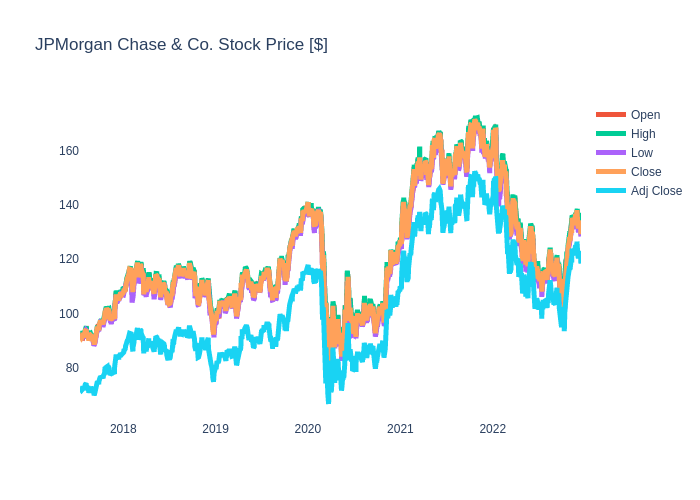

In [ ]:
# Plot interactive chart
plot_financial_data(JPM_df.drop(['Volume', 'Daily Return'], axis = 1), 'JPMorgan Chase & Co. Stock Price [$]')

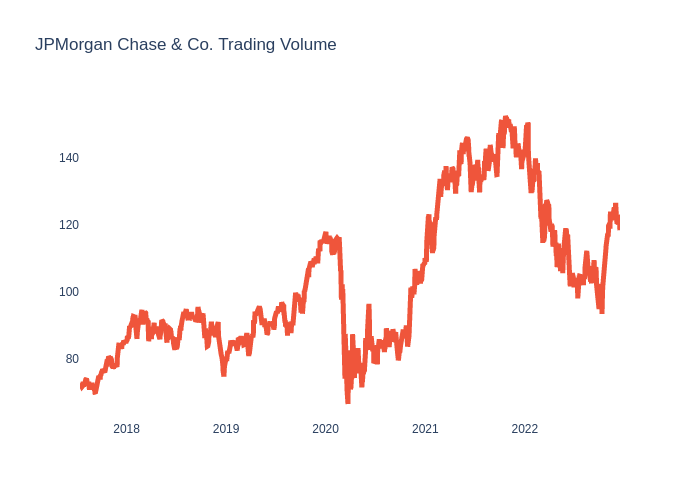

In [ ]:
# Plot trading volume (Note that the position of the Volume column is different compared to Amazon's DataFrame)
plot_financial_data(JPM_df.iloc[:,[0,6]], 'JPMorgan Chase & Co. Trading Volume')

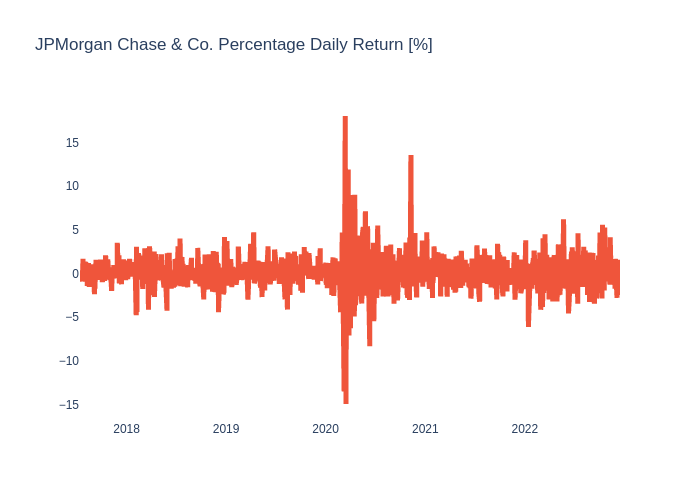

In [ ]:
# Plot % Daily Returns
plot_financial_data(JPM_df.iloc[:,[0,7]], 'JPMorgan Chase & Co. Percentage Daily Return [%]')

In [ ]:
# Apply the function to the "Daily Return" Column and place the result in "Trend" column
JPM_df['Trend'] = JPM_df['Daily Return'].apply(percentage_return_classifier)
JPM_df

,Date,Open,High,Low,Close,Volume,Adj Close,Daily Return,Trend
0,2017-07-14,90.809998,92.610001,90.580002,92.250000,22235200,72.654068,0.000000,Insignificant Change
1,2017-07-17,91.820000,91.989998,91.250000,91.389999,14374200,71.976768,-0.932225,Negative Change
2,2017-07-18,90.449997,91.580002,90.320000,91.070000,14719400,71.724754,-0.350133,Negative Change
3,2017-07-19,91.339996,91.620003,91.000000,91.199997,11651200,71.827133,0.142739,Insignificant Change
4,2017-07-20,91.150002,91.720001,90.900002,91.199997,11561700,71.827133,0.000000,Insignificant Change
...,...,...,...,...,...,...,...,...,...
1363,2022-12-12,132.399994,134.649994,131.600006,134.210007,8841600,122.901871,1.551150,Positive Change
1364,2022-12-13,136.889999,137.089996,133.080002,134.080002,10025400,122.782806,-0.096878,Insignificant Change
1365,2022-12-14,133.779999,135.710007,132.759995,133.410004,9966100,122.169281,-0.499683,Negative Change
1366,2022-12-15,131.149994,132.080002,129.050003,130.100006,12087800,119.138176,-2.481070,Negative Change


In [ ]:
# Count distinct values in the Trend column
trend_summary = JPM_df['Trend'].value_counts()
trend_summary

,count
Trend,
Positive Change,501
Negative Change,495
Insignificant Change,262
Large Positive Change,53
Large Negative Change,44
Bull Run,7
Bear Sell Off,6


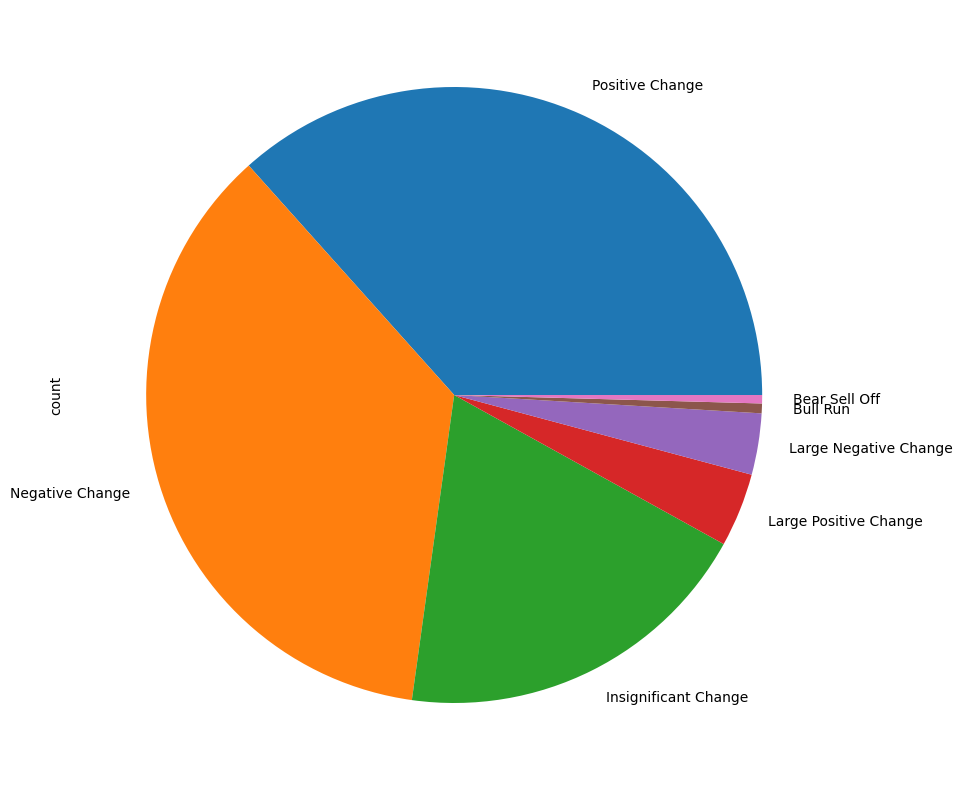

In [ ]:
# Plot a pie chart using Matplotlib Library
plt.figure(figsize = (10, 10))
trend_summary.plot(kind = 'pie', y = 'Trend');

In [ ]:
# Set the date to be the index for the Pandas DataFrame
# This is critical to show the date on the x-axis when using cufflinks
if JPM_df.index.name != 'Date':
    JPM_df.set_index(['Date'], inplace = True)
JPM_df

,Open,High,Low,Close,Volume,Adj Close,Daily Return,Trend
Date,,,,,,,,
2017-07-14,90.809998,92.610001,90.580002,92.250000,22235200,72.654068,0.000000,Insignificant Change
2017-07-17,91.820000,91.989998,91.250000,91.389999,14374200,71.976768,-0.932225,Negative Change
2017-07-18,90.449997,91.580002,90.320000,91.070000,14719400,71.724754,-0.350133,Negative Change
2017-07-19,91.339996,91.620003,91.000000,91.199997,11651200,71.827133,0.142739,Insignificant Change
2017-07-20,91.150002,91.720001,90.900002,91.199997,11561700,71.827133,0.000000,Insignificant Change
...,...,...,...,...,...,...,...,...
2022-12-12,132.399994,134.649994,131.600006,134.210007,8841600,122.901871,1.551150,Positive Change
2022-12-13,136.889999,137.089996,133.080002,134.080002,10025400,122.782806,-0.096878,Insignificant Change
2022-12-14,133.779999,135.710007,132.759995,133.410004,9966100,122.169281,-0.499683,Negative Change


In [ ]:
# Plot Candlestick Figure using Cufflinks
figure = cf.QuantFig(JPM_df, title = 'JPMorgan and Chase Co. Candlestick Chart', name = 'JPM')
figure.add_sma(periods=[30, 100], column = 'Close', color = ['magenta', 'green'])
figure.iplot(theme = 'white', up_color = 'green', down_color = 'red')

In [ ]:
# Plot Candlestick figure using Cufflinks
figure = cf.QuantFig(JPM_df, title = 'JPMorgan and Chase Co. Candlestick Chart', name = 'JPM')
# Let's display the bollinger bands
figure.add_bollinger_bands(periods = 20, boll_std = 2, colors = ['yellow', 'blue'], fill = True)
figure.iplot()

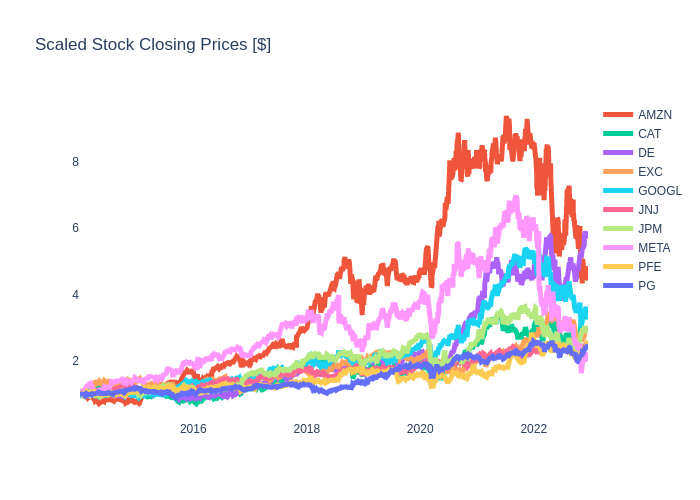

In [ ]:
# Plot scaled stock prices
plot_financial_data(price_scaling(close_price_df), 'Scaled Stock Closing Prices [$]')

### Practice opportunities - pesos aleatorios y simulacion con mas activos

In [ ]:
# Call the function (Run this cell multiple times to generate different outputs)
weights = generate_portfolio_weights(10)
print(weights)

[0.00465433 0.11708368 0.10714328 0.09176431 0.16975852 0.00992906
 0.21277627 0.20255858 0.05565853 0.02867344]


In [ ]:
# If you sum up all random weights, they should add up to 1
weights.sum()

1.0000000000000002

In [ ]:
# Run the code 3 times and record the final value of the portfolio along with the weights

# Portfolio Final Value in Run #1 = , weights =
# Portfolio Final Value in Run #2 = , weights =
# Portfolio Final Value in Run #3 = , weights =

In [ ]:
# Assume equal weights allocation
weights = np.ones(10) * 0.1
weights

array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])

In [ ]:
# Let's test out the "simulation_engine" function and print out statistical metrics
# Define the initial investment amount
initial_investment = 1000000
portfolio_metrics = simulation_engine(weights, initial_investment)

print('Expected Portfolio Annual Return = {:.2f}%'.format(portfolio_metrics[0] * 100))
print('Portfolio Standard Deviation (Volatility) = {:.2f}%'.format(portfolio_metrics[1] * 100))
print('Sharpe Ratio = {:.2f}'.format(portfolio_metrics[2]))
print('Portfolio Final Value = ${:.2f}'.format(portfolio_metrics[3]))
print('Return on Investment = {:.2f}%'.format(portfolio_metrics[4]))

Expected Portfolio Annual Return = 16.30%
Portfolio Standard Deviation (Volatility) = 18.02%
Sharpe Ratio = 0.74
Portfolio Final Value = $3203874.91
Return on Investment = 220.39%


In [ ]:
# Portfolio performance with equal weights allocation (Rf = 3%)
    # Expected Portfolio Annual Return = 16.30%
    # Portfolio Standard Deviation (Volatility) = 18.02%
    # Sharpe Ratio = 0.74
    # Portfolio Final Value = $3203874.76
    # Return on Investment = 220.39%

# Portfolio performance with equal weights allocation (Rf = 1%)
    # Expected Portfolio Annual Return = 16.30%
    # Portfolio Standard Deviation (Volatility) = 18.02%
    # Sharpe Ratio = 0.85
    # Portfolio Final Value = $3203874.76
    # Return on Investment = 220.39%

# For the same portfolio (with similar weights), lowering the risk-free rate will increase Sharpe ratio.

In [ ]:
# Return the minimum Sharpe ratio
sharpe_ratio_runs.min().round(4)
# Min Sharpe Ratio after 50 runs = 0.6406
# Min Sharpe Ratio after 10,000 runs = 0.5838

0.5909

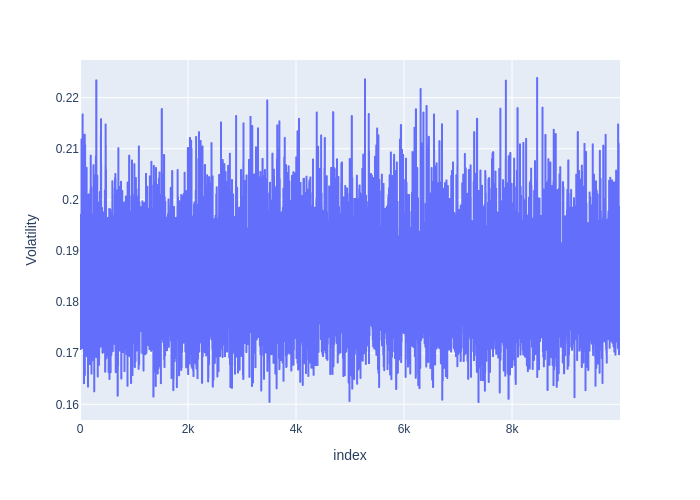

In [ ]:
# Plot interactive plot for volatility
fig = px.line(sim_out_df, y = 'Volatility')
fig.show()

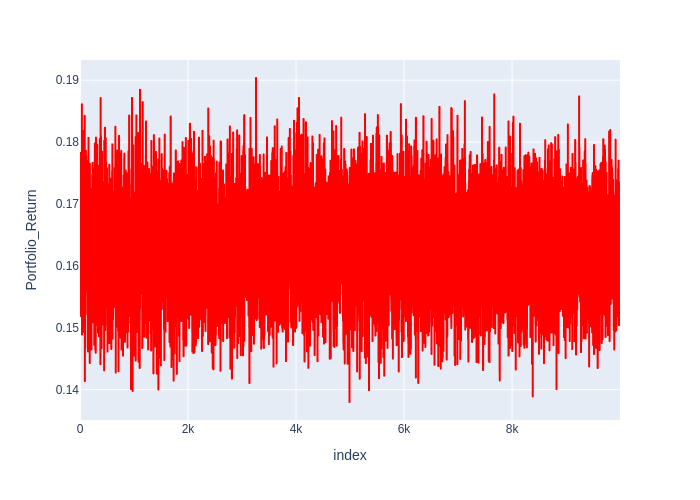

In [ ]:
# Plot interactive plot for Portfolio Return
fig = px.line(sim_out_df, y = 'Portfolio_Return')
fig.update_traces(line_color = 'red')
fig.show()

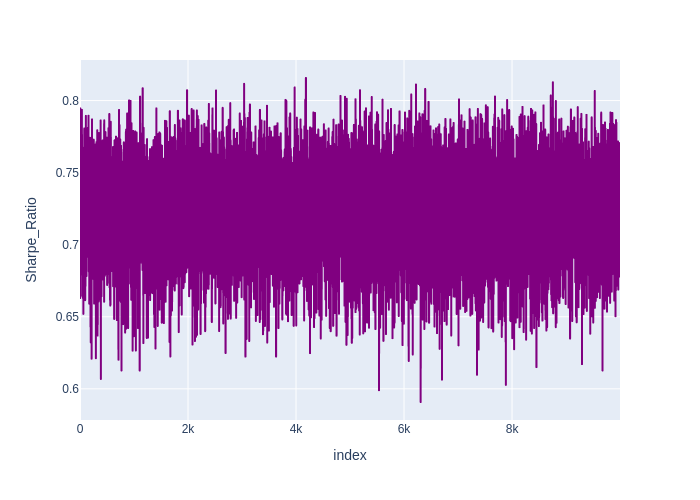

In [ ]:
# Plot interactive plot for Portfolio Return
fig = px.line(sim_out_df, y = 'Sharpe_Ratio')
fig.update_traces(line_color = 'purple')
fig.show()

## Appendix - como obtener los datos con pandas_datareader / yfinance

In [ ]:
# Code to obtain stock data using Pandas Datareader
# Select the start/end dates and ticker symbols
# Data is saved in a stock_data.csv file
tickers = ['AMZN', 'JPM', 'META', 'PG', 'GOOGL', 'CAT', 'PFE', 'EXC', 'DE', 'JNJ']
tickers = ['AMZN']

!pip install pandas_datareader
!pip install yfinance
from pandas_datareader import data as pdr
import yfinance as yfin
yfin.pdr_override()

# Indicate the start and end dates
start = dt.datetime(2018, 1, 1)
end = dt.datetime.now()

df = pdr.get_data_yahoo(tickers, start = start, end = end)
print(df)
df.to_csv('stock_data.csv')

AttributeError: module 'yfinance' has no attribute 'pdr_override'